# Phase 1bis — Audit de qualité

Ce notebook regarde **ce qui est cassé ou manquant** dans le dataset. Il porte sur
la totalité des données, saison de test incluse, et c'est volontaire : constater
qu'une colonne est à moitié vide ne nous apprend rien sur *comment prédire*, donc
ça ne constitue pas une fuite.

**Ce qui n'est pas ici.** Aucune corrélation avec le résultat, aucune recherche de
signal, aucune sélection de feature. Ça appartient à la Phase 2bis, qui sera filtrée
en dur sur les saisons d'entraînement. Regarder le signal sur le test, c'est choisir
ses features en ayant vu les réponses — une fuite qui passe par l'analyste et
qu'aucun test unitaire ne peut détecter.

Le notebook est **jetable et gitignoré**. Ce qui n'est pas recopié dans `JOURNAL.md`
est perdu.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.colors import LinearSegmentedColormap

# Validated categorical palette, fixed slot order. Never cycle these.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE, INK, INK_2, RULE = "#fcfcfb", "#0b0b0b", "#52514e", "#d8d7d2"
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
CMAP_BLUE = LinearSegmentedColormap.from_list("blue_seq", BLUE_RAMP)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 120, "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.edgecolor": RULE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.6,
    "legend.frameon": False, "lines.linewidth": 2,
})

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(190)
pl.Config.set_tbl_hide_dataframe_shape(True)

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIGDIR = ROOT / "reports" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)


def savefig(name: str) -> None:
    # Persist the figure under reports/ so the visuals outlive the notebook.
    plt.tight_layout()
    plt.savefig(FIGDIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


MATCHES = pl.read_parquet(ROOT / "data" / "raw" / "football_data.parquet")
SEASONS = sorted(MATCHES["season"].unique())
LEAGUES = sorted(MATCHES["league"].unique())
BOOKS = {"avg": "moyenne marché", "b365": "Bet365", "ps": "Pinnacle"}

print(f"{MATCHES.height} matchs, {MATCHES.width} colonnes")
MATCHES.head(3)

10734 matchs, 25 colonnes


league_code,date,kickoff_time,home_team,away_team,home_goals,away_goals,result,home_shots,away_shots,…,odds_close_ps_d,odds_close_ps_a,odds_close_b365_h,odds_close_b365_d,odds_close_b365_a,odds_close_avg_h,odds_close_avg_d,odds_close_avg_a,season,league
str,date,str,str,str,i64,i64,str,i64,i64,…,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""F1""",2020-08-21,"""18:00""","""Bordeaux""","""Nantes""",0,0,"""D""",5,6,…,2.97,3.02,2.62,2.87,3.1,2.65,2.93,3.01,"""2020-21""","""Ligue 1"""
"""F1""",2020-08-22,"""16:00""","""Dijon""","""Angers""",0,1,"""A""",9,12,…,3.07,2.44,3.25,3.1,2.35,3.3,3.02,2.39,"""2020-21""","""Ligue 1"""
"""F1""",2020-08-22,"""20:00""","""Lille""","""Rennes""",1,1,"""D""",5,16,…,3.47,4.52,1.85,3.4,4.2,1.89,3.38,4.38,"""2020-21""","""Ligue 1"""


## 1. Vue d'ensemble

Premier réflexe : est-ce que le périmètre est bien celui qu'on croit ? Six saisons,
cinq championnats, et une plage de dates cohérente.

In [2]:
print(f"matchs   : {MATCHES.height}")
print(f"periode  : {MATCHES['date'].min()} -> {MATCHES['date'].max()}")
print(f"ligues   : {LEAGUES}")
print(f"saisons  : {SEASONS}")
print(f"equipes  : {MATCHES['home_team'].n_unique()} noms distincts")
print(f"colonnes : {list(MATCHES.columns)}")

matchs   : 10734
periode  : 2020-08-21 -> 2026-05-24
ligues   : ['Bundesliga', 'La Liga', 'Ligue 1', 'Premier League', 'Serie A']
saisons  : ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
equipes  : 137 noms distincts
colonnes : ['league_code', 'date', 'kickoff_time', 'home_team', 'away_team', 'home_goals', 'away_goals', 'result', 'home_shots', 'away_shots', 'home_shots_target', 'away_shots_target', 'home_corners', 'away_corners', 'odds_close_ps_h', 'odds_close_ps_d', 'odds_close_ps_a', 'odds_close_b365_h', 'odds_close_b365_d', 'odds_close_b365_a', 'odds_close_avg_h', 'odds_close_avg_d', 'odds_close_avg_a', 'season', 'league']


## 2. Valeurs manquantes

Une colonne à trous ne plante pas : elle produit des nulls que le modèle avalera
sans rien dire. C'est donc le premier endroit à regarder.

In [3]:
nulls = (
    MATCHES.null_count()
    .transpose(include_header=True, header_name="colonne", column_names=["nulls"])
    .filter(pl.col("nulls") > 0)
    .with_columns((100 * pl.col("nulls") / MATCHES.height).round(2).alias("pct"))
    .sort("nulls", descending=True)
)
nulls

colonne,nulls,pct
str,u32,f64
"""odds_close_ps_h""",854,7.96
"""odds_close_ps_d""",854,7.96
"""odds_close_ps_a""",854,7.96
"""home_shots""",1,0.01
"""away_shots""",1,0.01
"""home_shots_target""",1,0.01
"""away_shots_target""",1,0.01
"""home_corners""",1,0.01
"""away_corners""",1,0.01


Les cotes Pinnacle manquent sur 8 % du dataset. Ce n'est pas réparti uniformément —
et c'est là que ça devient important.

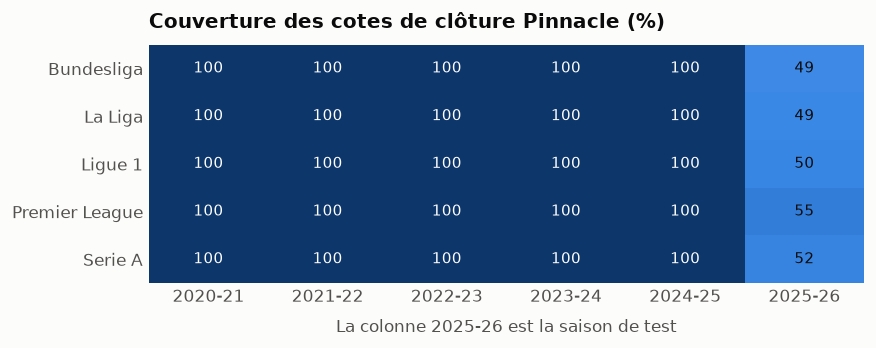

league,season,avg,b365,ps
str,str,f64,f64,f64
"""Bundesliga""","""2020-21""",100.0,100.0,100.0
"""Bundesliga""","""2021-22""",100.0,100.0,100.0
"""Bundesliga""","""2022-23""",100.0,100.0,100.0
"""Bundesliga""","""2023-24""",100.0,100.0,100.0
"""Bundesliga""","""2024-25""",100.0,100.0,100.0
"""Bundesliga""","""2025-26""",100.0,100.0,48.69281
"""La Liga""","""2020-21""",100.0,100.0,100.0
"""La Liga""","""2021-22""",100.0,100.0,100.0
"""La Liga""","""2022-23""",100.0,100.0,100.0


In [4]:
cov = (
    MATCHES.group_by("league", "season")
    .agg(*[(100 * (1 - pl.col(f"odds_close_{b}_h").null_count() / pl.len())).alias(b) for b in BOOKS])
    .sort("league", "season")
)
grid = np.array([[cov.filter((pl.col("league") == lg) & (pl.col("season") == s))["ps"][0]
                  for s in SEASONS] for lg in LEAGUES])

fig, ax = plt.subplots(figsize=(7.4, 3.0))
ax.imshow(grid, cmap=CMAP_BLUE, vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(SEASONS)), SEASONS)
ax.set_yticks(range(len(LEAGUES)), LEAGUES)
for i in range(len(LEAGUES)):
    for j in range(len(SEASONS)):
        v = grid[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9,
                color="#ffffff" if v > 60 else INK)
ax.set_title("Couverture des cotes de clôture Pinnacle (%)", pad=10, loc="left", fontweight="bold")
ax.set_xlabel("La colonne 2025-26 est la saison de test", labelpad=8)
for s in ax.spines.values():
    s.set_visible(False)
savefig("01_couverture_cotes")

cov

**Conséquence directe.** 2025-26 est la saison de test. Bâtir la baseline `market`
sur Pinnacle voudrait dire l'évaluer sur la moitié du test, sans qu'aucune erreur ne
soit levée. La colonne `avg` (moyenne de clôture du marché) couvre 100 % et devient
donc le candidat principal, avec Pinnacle en vérification croisée là où il existe.

## 3. Intégrité du calendrier

Un championnat à N équipes joue exactement `N × (N-1)` matchs, et chaque équipe en
joue `2 × (N-1)`. Tout écart est un bug d'ingestion, pas une curiosité.

In [5]:
expected = (
    MATCHES.group_by("league", "season")
    .agg(
        pl.len().alias("matchs"),
        pl.concat_list("home_team", "away_team").list.explode().n_unique().alias("equipes"),
    )
    .with_columns((pl.col("equipes") * (pl.col("equipes") - 1)).alias("attendu"))
    .with_columns((pl.col("matchs") - pl.col("attendu")).alias("ecart"))
    .sort("league", "season")
)
print(f"ligue-saisons incompletes : {expected.filter(pl.col('ecart') != 0).height}")

per_team = (
    pl.concat([
        MATCHES.select("league", "season", pl.col("home_team").alias("team")),
        MATCHES.select("league", "season", pl.col("away_team").alias("team")),
    ])
    .group_by("league", "season", "team")
    .agg(pl.len().alias("matchs"))
    .join(expected.select("league", "season", "equipes"), on=["league", "season"])
)
odd = per_team.filter(pl.col("matchs") != 2 * (pl.col("equipes") - 1))
print(f"equipes au compte de matchs anormal : {odd.height}")

key = ["date", "home_team", "away_team"]
print(f"cles (date, dom, ext) dupliquees : {MATCHES.filter(MATCHES.select(key).is_duplicated()).height}")
print(f"equipe contre elle-meme : {MATCHES.filter(pl.col('home_team') == pl.col('away_team')).height}")
expected

ligue-saisons incompletes : 0
equipes au compte de matchs anormal : 0
cles (date, dom, ext) dupliquees : 0
equipe contre elle-meme : 0


/var/folders/st/1vz5sld518b8mc815xq284p80000gn/T/ipykernel_5173/2373630439.py:5: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  pl.concat_list("home_team", "away_team").list.explode().n_unique().alias("equipes"),


league,season,matchs,equipes,attendu,ecart
str,str,u32,u32,u32,u32
"""Bundesliga""","""2020-21""",306,18,306,0
"""Bundesliga""","""2021-22""",306,18,306,0
"""Bundesliga""","""2022-23""",306,18,306,0
"""Bundesliga""","""2023-24""",306,18,306,0
"""Bundesliga""","""2024-25""",306,18,306,0
"""Bundesliga""","""2025-26""",306,18,306,0
"""La Liga""","""2020-21""",380,20,380,0
"""La Liga""","""2021-22""",380,20,380,0
"""La Liga""","""2022-23""",380,20,380,0


Les variations d'effectif sont réelles et non des bugs : la Bundesliga joue à 18
depuis toujours, la Ligue 1 est passée de 20 à 18 en 2023-24.

Les trous de calendrier méritent un coup d'œil, parce que la feature « jours de
repos » de la Phase 3 va les rencontrer.

In [6]:
(
    MATCHES.sort("date")
    .group_by("league", "season")
    .agg(pl.col("date").diff().max().dt.total_days().alias("trou_max_jours"))
    .sort("trou_max_jours", descending=True)
    .head(8)
)

league,season,trou_max_jours
str,str,i64
"""Bundesliga""","""2022-23""",68
"""Serie A""","""2022-23""",52
"""La Liga""","""2022-23""",49
"""Ligue 1""","""2022-23""",45
"""Premier League""","""2022-23""",43
"""Ligue 1""","""2023-24""",23
"""Bundesliga""","""2023-24""",23
"""Bundesliga""","""2021-22""",19


68 jours en Bundesliga 2022-23 : c'est la Coupe du monde au Qatar, jouée en plein
hiver européen. Un vrai événement, pas une donnée cassée.

## 4. Fréquences 1X2

C'est la matière première de la baseline `uniform`. Attention pour la Phase 2 : ces
fréquences devront être calculées **sur le train uniquement**, sinon la baseline
elle-même connaît le test.

In [7]:
def freq_by(key: str) -> pl.DataFrame:
    return (
        MATCHES.group_by(key)
        .agg(pl.len().alias("n"),
             *[(100 * (pl.col("result") == c).mean()).round(2).alias(lbl)
               for c, lbl in (("H", "dom"), ("D", "nul"), ("A", "ext"))])
        .sort(key)
    )

print("Global")
print(freq_by("result").drop("n") if False else
      MATCHES.group_by("result").agg((100 * pl.len() / MATCHES.height).round(2).alias("pct")).sort("result"))
print("\nPar saison")
print(freq_by("season"))
print("\nPar ligue")
print(freq_by("league"))

Global
┌────────┬───────┐
│ result ┆ pct   │
│ ---    ┆ ---   │
│ str    ┆ f64   │
╞════════╪═══════╡
│ A      ┆ 31.69 │
│ D      ┆ 25.4  │
│ H      ┆ 42.91 │
└────────┴───────┘

Par saison
┌─────────┬──────┬───────┬───────┬───────┐
│ season  ┆ n    ┆ dom   ┆ nul   ┆ ext   │
│ ---     ┆ ---  ┆ ---   ┆ ---   ┆ ---   │
│ str     ┆ u32  ┆ f64   ┆ f64   ┆ f64   │
╞═════════╪══════╪═══════╪═══════╪═══════╡
│ 2020-21 ┆ 1826 ┆ 39.87 ┆ 25.47 ┆ 34.67 │
│ 2021-22 ┆ 1826 ┆ 42.77 ┆ 25.85 ┆ 31.38 │
│ 2022-23 ┆ 1826 ┆ 45.73 ┆ 24.26 ┆ 30.01 │
│ 2023-24 ┆ 1752 ┆ 43.09 ┆ 26.43 ┆ 30.48 │
│ 2024-25 ┆ 1752 ┆ 42.01 ┆ 24.94 ┆ 33.05 │
│ 2025-26 ┆ 1752 ┆ 44.01 ┆ 25.46 ┆ 30.54 │
└─────────┴──────┴───────┴───────┴───────┘

Par ligue
┌────────────────┬──────┬───────┬───────┬───────┐
│ league         ┆ n    ┆ dom   ┆ nul   ┆ ext   │
│ ---            ┆ ---  ┆ ---   ┆ ---   ┆ ---   │
│ str            ┆ u32  ┆ f64   ┆ f64   ┆ f64   │
╞════════════════╪══════╪═══════╪═══════╪═══════╡
│ Bundesliga     ┆ 1836 ┆ 43.74 ┆

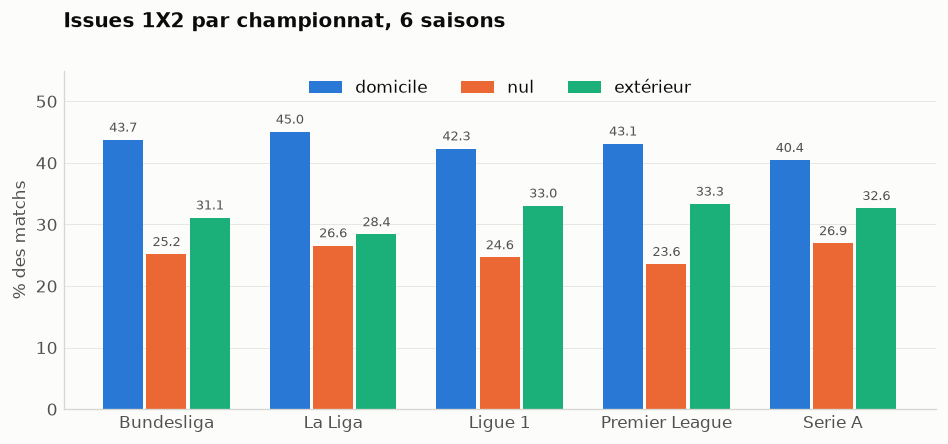

In [8]:
by_league = freq_by("league")
x = np.arange(len(by_league))
width = 0.26
fig, ax = plt.subplots(figsize=(8.0, 3.8))
for k, (col, colour, label) in enumerate(
    [("dom", BLUE, "domicile"), ("nul", ORANGE, "nul"), ("ext", AQUA, "extérieur")]
):
    vals = by_league[col].to_numpy()
    bars = ax.bar(x + (k - 1) * width, vals, width=width - 0.02, color=colour, label=label)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8, color=INK_2)

ax.set_xticks(x, by_league["league"].to_list())
ax.set_ylabel("% des matchs")
ax.set_ylim(0, 55)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend(ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
ax.set_title("Issues 1X2 par championnat, 6 saisons", pad=26, loc="left", fontweight="bold")
savefig("02_issues_1x2_par_ligue")

La Serie A a le plus faible avantage domicile (40.4 %) et le plus de nuls (26.9 %),
la Liga l'inverse. Des écarts de ce type entre championnats sont plausibles, mais
garde en tête l'ordre de grandeur du bruit calculé juste en dessous avant d'en tirer
une conclusion.

## 5. Avantage domicile dans le temps

Le point le plus important de cet audit. Trois mesures indépendantes de la même
chose : taux de victoire à domicile, différence de buts, différence de tirs.

In [9]:
by_season = (
    MATCHES.group_by("season")
    .agg(
        pl.len().alias("n"),
        (100 * (pl.col("result") == "H").mean()).alias("pct_dom"),
        (pl.col("home_goals") - pl.col("away_goals")).mean().round(3).alias("diff_buts"),
        (pl.col("home_shots") - pl.col("away_shots")).mean().round(2).alias("diff_tirs"),
    )
    .sort("season")
)
by_season.with_columns(pl.col("pct_dom").round(2))

season,n,pct_dom,diff_buts,diff_tirs
str,u32,f64,f64,f64
"""2020-21""",1826,39.87,0.152,1.49
"""2021-22""",1826,42.77,0.285,2.34
"""2022-23""",1826,45.73,0.35,2.44
"""2023-24""",1752,43.09,0.299,2.98
"""2024-25""",1752,42.01,0.172,2.18
"""2025-26""",1752,44.01,0.307,2.71


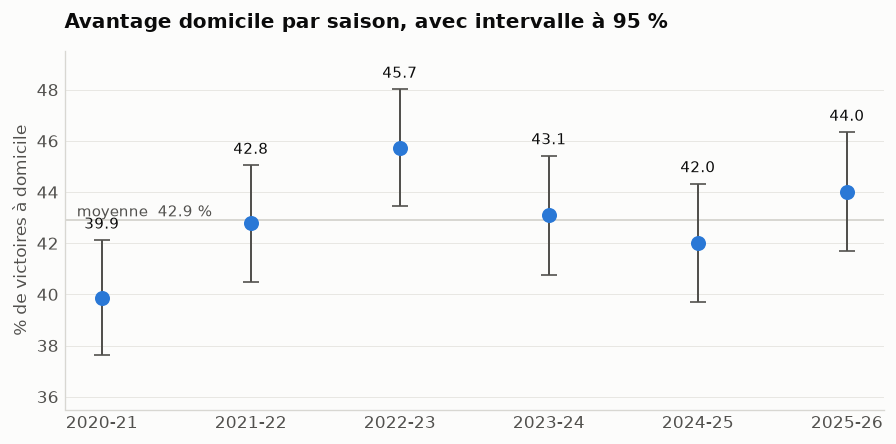

demi-intervalle a 95 % : +/- 2.29 points
Deux saisons dont les intervalles se recouvrent ne sont PAS distinguables.


In [10]:
n = by_season["n"].to_numpy()
p = by_season["pct_dom"].to_numpy() / 100
ci = 1.96 * np.sqrt(p * (1 - p) / n) * 100          # 95 % interval on a proportion
overall = 100 * (MATCHES["result"] == "H").mean()

fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.axhline(overall, color=RULE, linewidth=1.2, zorder=1)
# x in axes fraction, y in data units: keeps the label inside the frame.
ax.text(0.015, overall, f"moyenne  {overall:.1f} %", transform=ax.get_yaxis_transform(),
        ha="left", va="bottom", fontsize=9, color=INK_2)
ax.errorbar(SEASONS, p * 100, yerr=ci, fmt="o", markersize=8, color=BLUE,
            ecolor=INK_2, elinewidth=1.2, capsize=5, zorder=3)
for s, v, e in zip(SEASONS, p * 100, ci):
    ax.annotate(f"{v:.1f}", (s, v + e), xytext=(0, 7), textcoords="offset points",
                ha="center", fontsize=9, color=INK)
ax.set_ylabel("% de victoires à domicile")
ax.set_ylim(35.5, 49.5)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.set_title("Avantage domicile par saison, avec intervalle à 95 %", pad=14, loc="left",
             fontweight="bold")
savefig("03_avantage_domicile")

print(f"demi-intervalle a 95 % : +/- {ci.mean():.2f} points")
print("Deux saisons dont les intervalles se recouvrent ne sont PAS distinguables.")

**À toi.** Regarde 2020-21 sur les trois colonnes du tableau à la fois — taux, buts,
tirs — et dis-moi ce qui s'est passé cette saison-là. Puis dis-moi ce que ça implique
pour un modèle entraîné sur ces données et censé prédire 2025-26.

Et sers-toi de l'intervalle affiché avant de commenter les autres saisons : deux
points dont les barres se recouvrent ne sont pas distinguables, et raconter une
histoire sur leur écart, c'est commenter du bruit.

## 6. Distributions des variables de match

Rappel permanent : buts, tirs et corners sont des **résultats** du match. Ils ne
seront jamais des features de ce même match. On les regarde ici pour vérifier qu'ils
sont plausibles, pas pour prédire.

In [11]:
STATS = ["home_goals", "away_goals", "home_shots", "away_shots",
         "home_shots_target", "away_shots_target", "home_corners", "away_corners"]
(
    MATCHES.select(STATS).describe()
    .filter(pl.col("statistic").is_in(["null_count", "mean", "std", "min", "50%", "max"]))
)

statistic,home_goals,away_goals,home_shots,away_shots,home_shots_target,away_shots_target,home_corners,away_corners
str,f64,f64,f64,f64,f64,f64,f64,f64
"""null_count""",0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
"""mean""",1.534749,1.273896,13.582037,11.231343,4.800522,3.988167,5.298612,4.346315
"""std""",1.300565,1.165626,5.336209,4.794593,2.567935,2.334166,2.938428,2.608434
"""min""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",1.0,1.0,13.0,11.0,4.0,4.0,5.0,4.0
"""max""",9.0,8.0,46.0,37.0,20.0,20.0,26.0,19.0


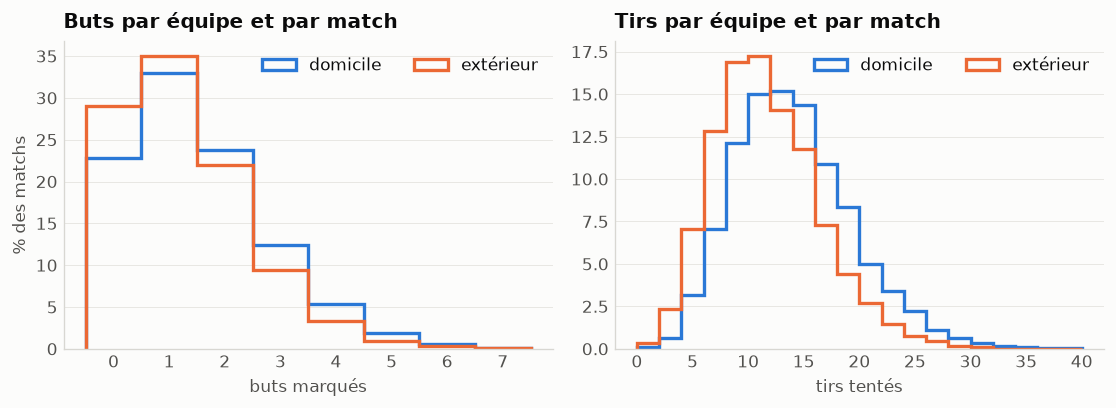

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.5))

bins = np.arange(-0.5, 8.5)
for col, colour, label in [("home_goals", BLUE, "domicile"), ("away_goals", ORANGE, "extérieur")]:
    vals = MATCHES[col].drop_nulls().to_numpy()
    axes[0].hist(vals, bins=bins, histtype="step", linewidth=2, color=colour, label=label,
                 weights=np.full(len(vals), 100 / len(vals)))
axes[0].set_xlabel("buts marqués")
axes[0].set_ylabel("% des matchs")
axes[0].set_title("Buts par équipe et par match", loc="left", fontweight="bold", pad=8)
axes[0].legend(ncols=2)

for col, colour, label in [("home_shots", BLUE, "domicile"), ("away_shots", ORANGE, "extérieur")]:
    vals = MATCHES[col].drop_nulls().to_numpy()
    axes[1].hist(vals, bins=np.arange(0, 42, 2), histtype="step", linewidth=2, color=colour,
                 label=label, weights=np.full(len(vals), 100 / len(vals)))
axes[1].set_xlabel("tirs tentés")
axes[1].set_title("Tirs par équipe et par match", loc="left", fontweight="bold", pad=8)
axes[1].legend(ncols=2)

for ax in axes:
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
savefig("04_distributions_buts_tirs")

L'écart domicile/extérieur se voit sur les deux distributions, décalées mais de même
forme. Les buts suivent l'allure quasi-Poisson attendue : beaucoup de 0, 1 et 2, une
queue fine au-delà. Retiens la variance : c'est pour ça que le xG, qui mesure la même
force sous-jacente avec moins de bruit, vaudrait le détour.

## 7. Marge des bookmakers

La somme des probabilités implicites dépasse 1. L'excédent est la marge, et il faut
la retirer avant de comparer quoi que ce soit au marché.

In [13]:
sums = {}
rows = []
for book, label in BOOKS.items():
    cols = [f"odds_close_{book}_{o}" for o in "hda"]
    s = MATCHES.drop_nulls(cols).select(
        sum(1 / pl.col(c) for c in cols).alias("s")
    )["s"]
    sums[label] = s.to_numpy()
    rows.append({"bookmaker": label, "n": len(s),
                 "overround_pct": round(100 * (s.mean() - 1), 2),
                 "median": round(s.median(), 4),
                 "min": round(s.min(), 4), "max": round(s.max(), 4),
                 "sous_1": int((s < 1).sum())})
pl.DataFrame(rows)

bookmaker,n,overround_pct,median,min,max,sous_1
str,i64,f64,f64,f64,f64,i64
"""moyenne marché""",10734,4.73,1.0454,0.9287,1.0755,1
"""Bet365""",10733,5.59,1.0559,1.0173,1.1239,0
"""Pinnacle""",9880,2.67,1.0266,1.0005,1.0719,0


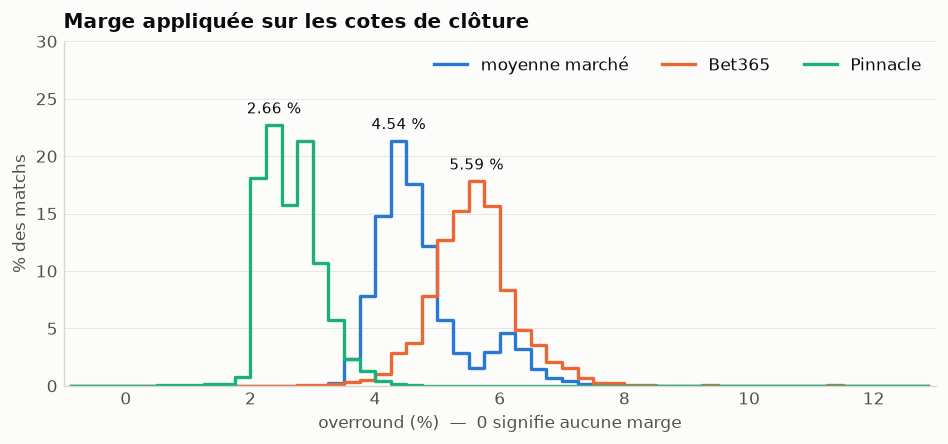

In [14]:
bins = np.arange(-1, 13.25, 0.25)
centers = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots(figsize=(8.0, 3.8))
for (label, vals), colour in zip(sums.items(), [BLUE, ORANGE, AQUA]):
    over = 100 * (vals - 1)
    height = 100 * np.histogram(over, bins=bins)[0] / len(over)
    ax.step(centers, height, where="mid", linewidth=2, color=colour, label=label)
    # Direct-label the median at each curve's own peak: identity from the legend,
    # value from the label, and nothing lands on top of another series.
    ax.annotate(f"{np.median(over):.2f} %", (centers[height.argmax()], height.max()),
                xytext=(0, 7), textcoords="offset points", ha="center",
                fontsize=9, color=INK)
ax.set_xlabel("overround (%)  —  0 signifie aucune marge")
ax.set_ylabel("% des matchs")
ax.set_xlim(-1, 13)
ax.set_ylim(0, 30)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend(ncols=3, loc="upper right")
ax.set_title("Marge appliquée sur les cotes de clôture", loc="left", fontweight="bold", pad=8)
savefig("05_marge_bookmakers")

Pinnacle à 2.67 % contre 5.59 % pour Bet365 : ce n'est pas un détail. Une marge
faible signifie que le book accepte les gros paris et vit du volume, donc que son
prix est corrigé par des gens informés. C'est la référence la plus dure à battre.

## 8. Anomalies retenues

Trois choses cassées, à décider : bloquantes ou acceptables ?

In [15]:
print("--- A. Le match sans statistiques ---")
print(MATCHES.filter(pl.col("home_shots").is_null())
      .select("date", "league", "home_team", "away_team", "home_goals", "away_goals",
              "result", "home_shots", "odds_close_b365_h", "odds_close_avg_h"))

print("\n--- B. Lignes de cotes incoherentes : probas implicites sommant a moins de 1 ---")
avg = [f"odds_close_avg_{o}" for o in "hda"]
print(MATCHES.with_columns(sum(1 / pl.col(c) for c in avg).alias("somme_avg"))
      .filter(pl.col("somme_avg") < 1)
      .select("date", "league", "home_team", "away_team", *avg,
              *[f"odds_close_ps_{o}" for o in "hda"], "somme_avg"))

print("\n--- C. Le nul donne favori, ce qui n'arrive jamais au football ---")
print(MATCHES.filter((pl.col("odds_close_avg_d") < pl.col("odds_close_avg_h"))
                     & (pl.col("odds_close_avg_d") < pl.col("odds_close_avg_a")))
      .select("date", "league", "home_team", "away_team", *avg,
              *[f"odds_close_ps_{o}" for o in "hda"]))

--- A. Le match sans statistiques ---
┌────────────┬────────────┬──────────────┬───────────┬────────────┬────────────┬────────┬────────────┬───────────────────┬──────────────────┐
│ date       ┆ league     ┆ home_team    ┆ away_team ┆ home_goals ┆ away_goals ┆ result ┆ home_shots ┆ odds_close_b365_h ┆ odds_close_avg_h │
│ ---        ┆ ---        ┆ ---          ┆ ---       ┆ ---        ┆ ---        ┆ ---    ┆ ---        ┆ ---               ┆ ---              │
│ date       ┆ str        ┆ str          ┆ str       ┆ i64        ┆ i64        ┆ str    ┆ i64        ┆ f64               ┆ f64              │
╞════════════╪════════════╪══════════════╪═══════════╪════════════╪════════════╪════════╪════════════╪═══════════════════╪══════════════════╡
│ 2024-12-14 ┆ Bundesliga ┆ Union Berlin ┆ Bochum    ┆ 0          ┆ 2          ┆ A      ┆ null       ┆ 1.65              ┆ 1.64             │
└────────────┴────────────┴──────────────┴───────────┴────────────┴────────────┴────────┴────────────┴────────

Le nul favori est mathématiquement impossible sur un marché sain, donc la ligne est
corrompue à la source. Pinnacle donne un prix sain sur le même match, ce qui confirme
que le problème est dans la colonne `avg` et pas dans le match.

Reste à savoir si `avg` est utilisable malgré ces quelques lignes. On le mesure en
comparant les deux sources là où elles coexistent — un contrôle de cohérence entre
cotes, qui n'utilise aucun résultat et ne leake donc pas.

In [16]:
ps = [f"odds_close_ps_{o}" for o in "hda"]
both = MATCHES.drop_nulls(avg + ps).with_columns(
    *[(1 / pl.col(avg[i]) / sum(1 / pl.col(c) for c in avg)
       - 1 / pl.col(ps[i]) / sum(1 / pl.col(c) for c in ps)).abs().alias(f"e_{o}")
      for i, o in enumerate("hda")]
).with_columns(pl.max_horizontal("e_h", "e_d", "e_a").alias("ecart_max"))

print(f"n = {both.height} matchs ou les deux sources existent")
for t in (1, 2, 5):
    k = (both["ecart_max"] > t / 100).sum()
    print(f"  ecart > {t} point : {k:5d} matchs  ({100 * k / both.height:5.2f} %)")
print(f"\necart absolu moyen : {100 * both['ecart_max'].mean():.2f} points")

n = 9880 matchs ou les deux sources existent
  ecart > 1 point :  2247 matchs  (22.74 %)
  ecart > 2 point :   224 matchs  ( 2.27 %)
  ecart > 5 point :     6 matchs  ( 0.06 %)

ecart absolu moyen : 0.75 points


Les deux sources disent la même chose à une fraction de point près sur la quasi-totalité
des matchs. `avg` est donc utilisable comme baseline `market`, à condition d'ajouter un
contrôle qui rejette les lignes incohérentes.

---

## Ce qu'il faut écrire dans `JOURNAL.md`

Ce notebook disparaît. Recopie :

1. Les anomalies que tu retiens, et pour chacune : bloquante ou acceptable, et pourquoi.
2. Ta décision sur la baseline `market` : quelle colonne, avec quel contrôle.
3. Ta réponse au checkpoint : ce qui s'est passé en 2020-21, et ce que ça implique
   pour l'entraînement.